# 1. Environment Setup

In [40]:
# Import the libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import date
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
from scipy.stats import zscore

In [41]:
import os

print(os.getcwd())
print(os.listdir("../../data/raw"))

n:\-LEARNING\--Portfolio\time-series-forecasting-project\notebooks\week1
['holidays.csv', 'oil.csv', 'stores.csv', 'timeseries.csv']


In [42]:
plt.style.use("default")

In [43]:
import matplotlib as mpl
import matplotlib.pyplot as plt

plt.style.use("default")
mpl.rcParams["figure.facecolor"] = "white"
mpl.rcParams["axes.facecolor"] = "white"
mpl.rcParams["savefig.facecolor"] = "white"
mpl.rcParams["text.color"] = "black"
mpl.rcParams["axes.labelcolor"] = "black"
mpl.rcParams["xtick.color"] = "black"
mpl.rcParams["ytick.color"] = "black"
mpl.rcParams["axes.edgecolor"] = "black"

# 2. Data Loading

In [44]:
# Import holidays dataset
df_holidays = pd.read_csv("../../data/raw/holidays.csv")
display(df_holidays.head())

,date,locale,locale_name,description
0,2012-03-02,Local,Manta,Fundacion de Manta
1,2012-04-01,Regional,Cotopaxi,Provincializacion de Cotopaxi
2,2012-04-12,Local,Cuenca,Fundacion de Cuenca
3,2012-04-14,Local,Libertad,Cantonizacion de Libertad
4,2012-04-21,Local,Riobamba,Cantonizacion de Riobamba


In [45]:
# Import oil dataset
df_oil = pd.read_csv("../../data/raw/oil.csv")
display(df_oil.head())

,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20


In [46]:
# Import stories dataset
df_stores = pd.read_csv("../../data/raw/stores.csv")
display(df_stores.head())

,store_nbr,city,region
0,1,Quito,Pichincha
1,2,Quito,Pichincha
2,3,Quito,Pichincha
3,4,Quito,Pichincha
4,5,Santo Domingo,Santo Domingo de los Tsachilas


In [47]:
# Import timeseries dataset
df_timeseries = pd.read_csv("../../data/raw/timeseries.csv")
display(df_timeseries.head())

,date,unit_sales
0,2013-01-02,582.0
1,2013-01-03,310.0
2,2013-01-04,338.0
3,2013-01-05,654.0
4,2013-01-06,979.0


# 3. Dataset Overview

In [48]:
# Check the size of each dataset
print("Holidays:", df_holidays.shape)
print("Stores:", df_stores.shape)
print("Oil:", df_oil.shape)
print("Time Series:", df_timeseries.shape)

Holidays: (350, 4)
Stores: (54, 3)
Oil: (1218, 2)
Time Series: (452, 2)


In [49]:
# Inspect column names in each dataset
print("Holidays columns:", df_holidays.columns.tolist())
print("Stores columns:", df_stores.columns.tolist())
print("Oil columns:", df_oil.columns.tolist())
print("Time Series columns:", df_timeseries.columns.tolist())

Holidays columns: ['date', 'locale', 'locale_name', 'description']
Stores columns: ['store_nbr', 'city', 'region']
Oil columns: ['date', 'dcoilwtico']
Time Series columns: ['date', 'unit_sales']


In [50]:
# Check data types in each dataset
print("Holidays dtypes:\n", df_holidays.dtypes, "\n")
print("Stores dtypes:\n", df_stores.dtypes, "\n")
print("Oil dtypes:\n", df_oil.dtypes, "\n")
print("Time Series dtypes:\n", df_timeseries.dtypes)

Holidays dtypes:
 date           str
locale         str
locale_name    str
description    str
dtype: object 

Stores dtypes:
 store_nbr    int64
city           str
region         str
dtype: object 

Oil dtypes:
 date              str
dcoilwtico    float64
dtype: object 

Time Series dtypes:
 date              str
unit_sales    float64
dtype: object


In [51]:
# Convert date columns to datetime
df_holidays["date"] = pd.to_datetime(df_holidays["date"])
df_oil["date"] = pd.to_datetime(df_oil["date"])
df_timeseries["date"] = pd.to_datetime(df_timeseries["date"])

In [52]:
# Verify datetime conversion
print("Holidays date dtype:", df_holidays["date"].dtype)
print("Oil date dtype:", df_oil["date"].dtype)
print("Time Series date dtype:", df_timeseries["date"].dtype)

Holidays date dtype: datetime64[us]
Oil date dtype: datetime64[us]
Time Series date dtype: datetime64[us]


In [53]:
# Inspect summary statistics for key numeric columns
display(df_timeseries.describe())
display(df_oil.describe())

,date,unit_sales
count,452,452.000000
mean,2013-08-15 21:46:11.681416,480.090708
min,2013-01-02 00:00:00,4.000000
25%,2013-04-24 18:00:00,358.000000
50%,2013-08-15 12:00:00,445.500000
75%,2013-12-06 06:00:00,578.250000
max,2014-03-31 00:00:00,1203.000000
std,NaN,170.839776


,date,dcoilwtico
count,1218,1175.000000
mean,2015-05-02 12:00:00,67.714366
min,2013-01-01 00:00:00,26.190000
25%,2014-03-03 06:00:00,46.405000
50%,2015-05-02 12:00:00,53.190000
75%,2016-06-30 18:00:00,95.660000
max,2017-08-31 00:00:00,110.620000
std,NaN,25.630476


In [54]:
# Check date ranges for the main time-based datasets
print("Time series date range:", df_timeseries["date"].min(), "to", df_timeseries["date"].max())
print("Oil date range:", df_oil["date"].min(), "to", df_oil["date"].max())
print("Holidays date range:", df_holidays["date"].min(), "to", df_holidays["date"].max())

Time series date range: 2013-01-02 00:00:00 to 2014-03-31 00:00:00
Oil date range: 2013-01-01 00:00:00 to 2017-08-31 00:00:00
Holidays date range: 2012-03-02 00:00:00 to 2017-12-26 00:00:00


# 4. Calendar and Timeline Completeness Check

Before continuing with time series analysis, it is important to verify that the main sales time series contains a complete daily timeline.
Missing dates can create problems for forecasting models because time series models usually expect observations to be ordered and regularly spaced.
In this section, we check whether all expected daily dates are present in the sales time series. If missing dates are found, they are added back to create a continuous daily timeline.

In [55]:
# Check whether the main time series has a complete daily timeline

df_timeseries = df_timeseries.sort_values("date").reset_index(drop=True)

expected_dates = pd.date_range(
    start=df_timeseries["date"].min(),
    end=df_timeseries["date"].max(),
    freq="D"
)

actual_dates = pd.DatetimeIndex(df_timeseries["date"].drop_duplicates())

missing_dates = expected_dates.difference(actual_dates)

print(f"Start date: {df_timeseries['date'].min().date()}")
print(f"End date: {df_timeseries['date'].max().date()}")
print(f"Expected number of days: {len(expected_dates)}")
print(f"Actual number of unique dates: {df_timeseries['date'].nunique()}")
print(f"Number of missing dates: {len(missing_dates)}")

if len(missing_dates) > 0:
    print("Missing dates:")
    print(missing_dates)
else:
    print("No missing dates found. The daily timeline is complete.")

Start date: 2013-01-02
End date: 2014-03-31
Expected number of days: 454
Actual number of unique dates: 452
Number of missing dates: 2
Missing dates:
DatetimeIndex(['2013-12-25', '2014-01-01'], dtype='datetime64[us]', freq=None)


In [56]:
# Reindex the time series to a complete daily timeline

df_timeseries = (
    df_timeseries
    .set_index("date")
    .sort_index()
    .reindex(expected_dates)
)

df_timeseries.index.name = "date"
df_timeseries = df_timeseries.reset_index()

print("Missing dates were added back to the time series.")
print(f"New dataset shape: {df_timeseries.shape}")

# Check missing values after reindexing
print("\nMissing values after reindexing:")
print(df_timeseries.isna().sum())

Missing dates were added back to the time series.
New dataset shape: (454, 2)

Missing values after reindexing:
date          0
unit_sales    2
dtype: int64


In [57]:
# Fill missing unit_sales values created by reindexing

missing_sales_after_reindexing = df_timeseries["unit_sales"].isna().sum()

print(f"Missing unit_sales values after reindexing: {missing_sales_after_reindexing}")

if missing_sales_after_reindexing > 0:
    df_timeseries["unit_sales"] = df_timeseries["unit_sales"].interpolate(method="linear")
    df_timeseries["unit_sales"] = df_timeseries["unit_sales"].ffill().bfill()

    print("Missing unit_sales values were filled using linear interpolation.")
    print("Remaining missing unit_sales values:", df_timeseries["unit_sales"].isna().sum())
else:
    print("No missing unit_sales values need to be filled.")

Missing unit_sales values after reindexing: 2
Missing unit_sales values were filled using linear interpolation.
Remaining missing unit_sales values: 0


In [58]:
# Final check: confirm that the cleaned time series has a continuous daily frequency

date_differences = df_timeseries["date"].sort_values().diff().dropna()

print(date_differences.value_counts().head())

if (date_differences == pd.Timedelta(days=1)).all():
    print("Final check passed: the time series has a continuous daily frequency.")
else:
    print("Warning: the time series still contains irregular date gaps.")

date
1 days    453
Name: count, dtype: int64
Final check passed: the time series has a continuous daily frequency.


The timeline completeness check showed that two dates were missing from the daily sales time series: 2013-12-25 and 2014-01-01.

These dates were added back to create a continuous daily timeline. The missing `unit_sales` values created by this correction were filled using linear interpolation.

Because the dataset is aggregated and simplified, interpolation was selected instead of assuming zero sales for the missing dates. This avoids introducing artificial drops into the time series without clear evidence that sales were actually zero on those dates.

After this correction, the time series has a regular daily frequency and is suitable for decomposition, stationarity analysis, feature engineering, and forecasting models.

# 5. Initial Time Series Inspection

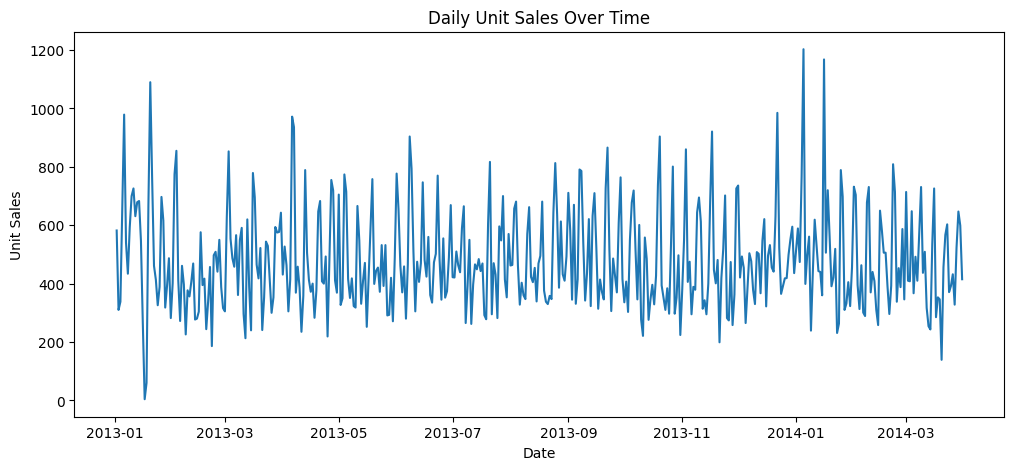

In [59]:
# Plot the main time series
plt.figure(figsize=(12, 5))
plt.plot(df_timeseries["date"], df_timeseries["unit_sales"])
plt.title("Daily Unit Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Unit Sales")
plt.show()

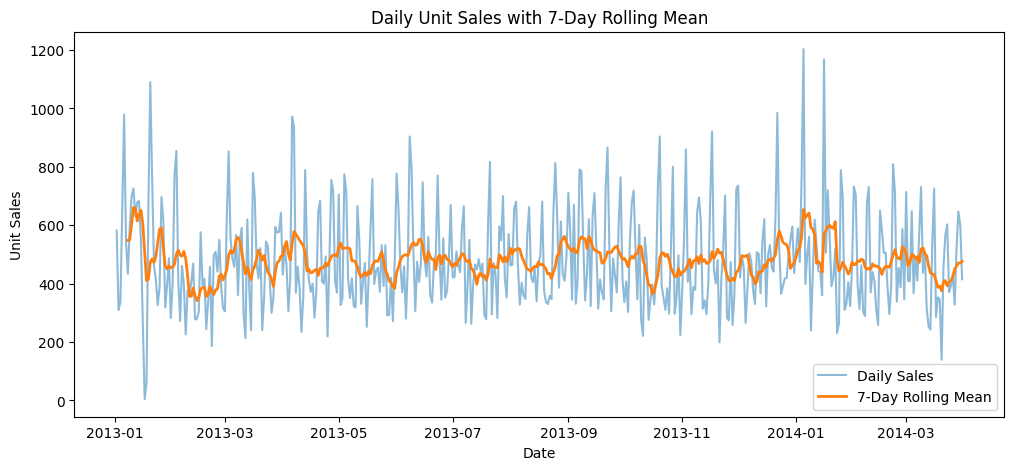

In [60]:
# Plot the time series with a 7-day rolling mean
df_timeseries["rolling_mean_7"] = df_timeseries["unit_sales"].rolling(window=7).mean()

plt.figure(figsize=(12, 5))
plt.plot(df_timeseries["date"], df_timeseries["unit_sales"], alpha=0.5, label="Daily Sales")
plt.plot(df_timeseries["date"], df_timeseries["rolling_mean_7"], linewidth=2, label="7-Day Rolling Mean")
plt.title("Daily Unit Sales with 7-Day Rolling Mean")
plt.xlabel("Date")
plt.ylabel("Unit Sales")
plt.legend()
plt.show()

The daily sales series is highly volatile, with frequent short-term fluctuations and several visible spikes. The 7-day rolling mean smooths the daily noise and suggests that the average sales level remains relatively stable over time, with only moderate local changes. At this stage, there is no strong long-term upward or downward trend, but several unusual peaks should be examined more closely.

# 6. Distribution of Unit Sales

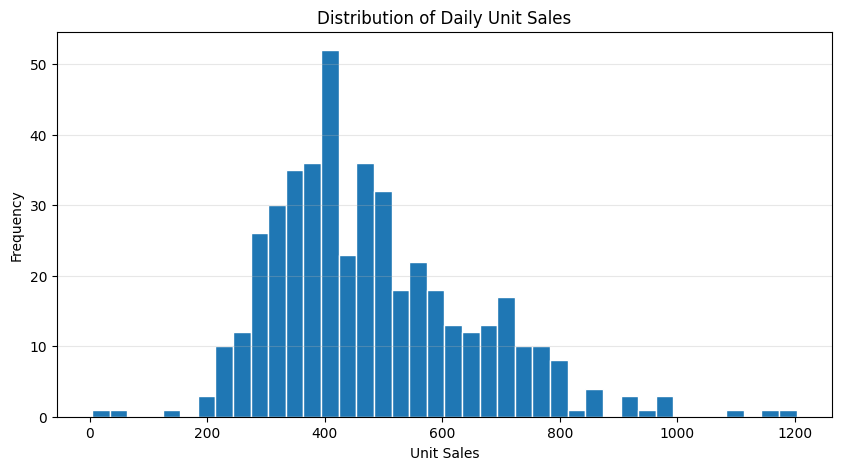

In [61]:
# Plot a clearer distribution of daily unit sales
plt.figure(figsize=(10, 5))
plt.hist(df_timeseries["unit_sales"], bins=40, edgecolor="white")
plt.title("Distribution of Daily Unit Sales")
plt.xlabel("Unit Sales")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.3)
plt.show()

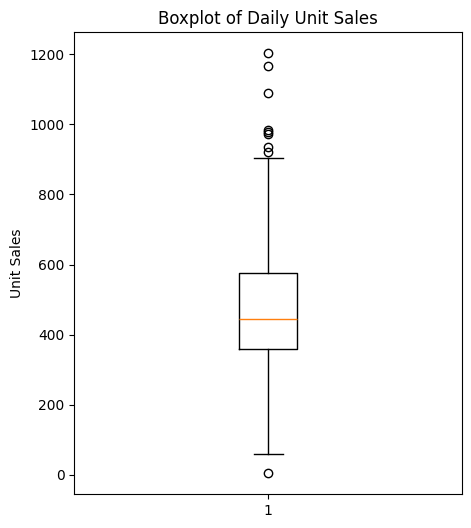

In [62]:
# Plot a vertical boxplot to inspect potential outliers
plt.figure(figsize=(5, 6))
plt.boxplot(df_timeseries["unit_sales"])
plt.title("Boxplot of Daily Unit Sales")
plt.ylabel("Unit Sales")
plt.show()

The distribution of daily unit sales is positively skewed, with most observations concentrated in the mid-range and a smaller number of unusually high values. The boxplot confirms the presence of several potential upper outliers, as well as at least one very low value near zero. These observations should be reviewed further before deciding whether they represent data issues or valid business events.

# 7. Missing Values Analysis

In [63]:
# Check missing values in each dataset
print("Holidays missing values:\n", df_holidays.isna().sum(), "\n")
print("Stores missing values:\n", df_stores.isna().sum(), "\n")
print("Oil missing values:\n", df_oil.isna().sum(), "\n")
print("Time Series missing values:\n", df_timeseries.isna().sum())

Holidays missing values:
 date           0
locale         0
locale_name    0
description    0
dtype: int64 

Stores missing values:
 store_nbr    0
city         0
region       0
dtype: int64 

Oil missing values:
 date           0
dcoilwtico    43
dtype: int64 

Time Series missing values:
 date              0
unit_sales        0
rolling_mean_7    6
dtype: int64


The main time series does not contain missing values in the `date` or `unit_sales` columns, which is a good starting point for further analysis. The oil dataset contains 43 missing values in the oil price column, which may require treatment if this table is later used for additional analysis or merging. The missing values in `rolling_mean_7` are expected because a 7-day rolling average cannot be calculated for the first six observations.

# 8. Oil Price Missing Values

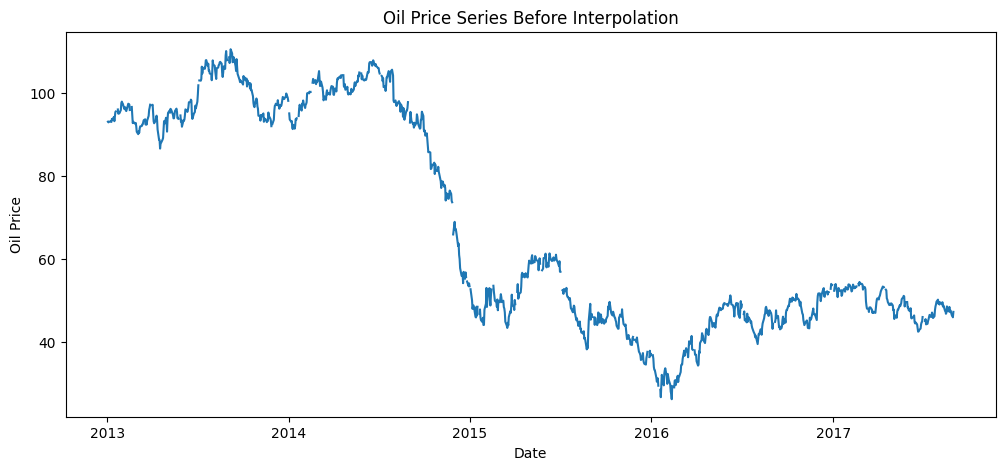

In [64]:
# Plot the oil price series before handling missing values
plt.figure(figsize=(12, 5))
plt.plot(df_oil["date"], df_oil["dcoilwtico"])
plt.title("Oil Price Series Before Interpolation")
plt.xlabel("Date")
plt.ylabel("Oil Price")
plt.show()

In [65]:
# Fill missing oil prices using linear interpolation
df_oil["oil_price_interpolated"] = df_oil["dcoilwtico"].interpolate(method="linear")

In [66]:
# Check missing values after interpolation
print(df_oil[["dcoilwtico", "oil_price_interpolated"]].isna().sum())

dcoilwtico                43
oil_price_interpolated     1
dtype: int64


In [67]:
# Find rows where the interpolated oil price is still missing
df_oil[df_oil["oil_price_interpolated"].isna()]

,date,dcoilwtico,oil_price_interpolated
0,2013-01-01,NaN,NaN


In [68]:
# Fill the remaining missing value at the start of the series
df_oil["oil_price_interpolated"] = df_oil["oil_price_interpolated"].bfill()

In [69]:
print(df_oil[["dcoilwtico", "oil_price_interpolated"]].isna().sum())

dcoilwtico                43
oil_price_interpolated     0
dtype: int64


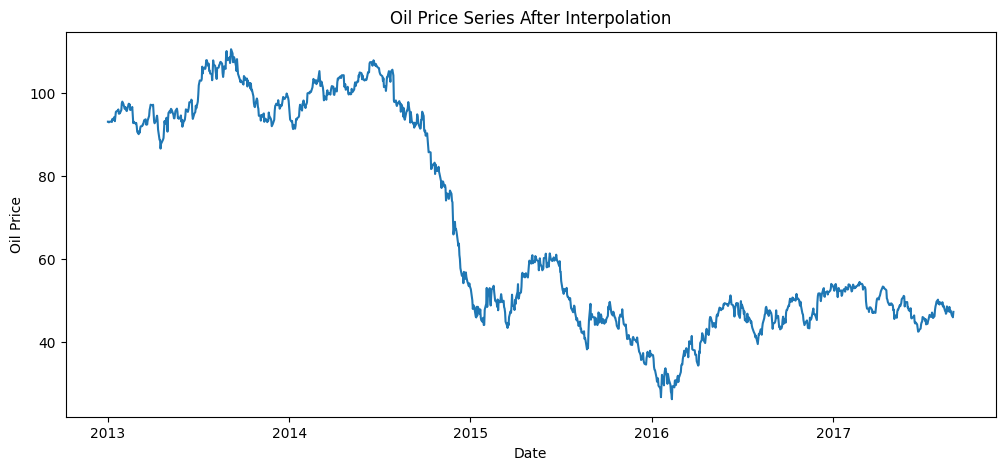

In [70]:
# Plot the oil price series after interpolation
plt.figure(figsize=(12, 5))
plt.plot(df_oil["date"], df_oil["oil_price_interpolated"])
plt.title("Oil Price Series After Interpolation")
plt.xlabel("Date")
plt.ylabel("Oil Price")
plt.show()

The oil dataset initially contained missing values in the `dcoilwtico` column. These were handled by applying linear interpolation and then backfilling the first remaining missing observation at the start of the series. The resulting `oil_price_interpolated` column contains no missing values and provides a continuous supporting time series for further analysis if needed.

In [71]:
# Save the oil dataset with the interpolated price column
df_oil.to_csv("../../data/processed/oil_interpolated.csv", index=False)

# 9. Seasonal Decomposition

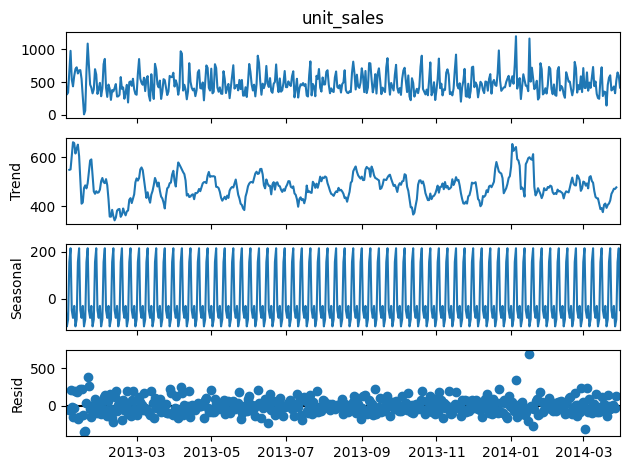

In [72]:
# Prepare the time series for seasonal decomposition
ts = df_timeseries.copy()
ts = ts.sort_values("date")
ts = ts.set_index("date")

decomposition = seasonal_decompose(ts["unit_sales"], model="additive", period=7)
decomposition.plot()
plt.show()

The seasonal decomposition suggests that the time series contains a clear repeating weekly pattern, which supports the choice of a 7-day seasonal period. The trend component shows moderate local changes over time, but no strong long-term upward or downward movement. The residual component still contains substantial variation, indicating that not all fluctuations are explained by trend and weekly seasonality alone.

# 10. Stationarity Analysis

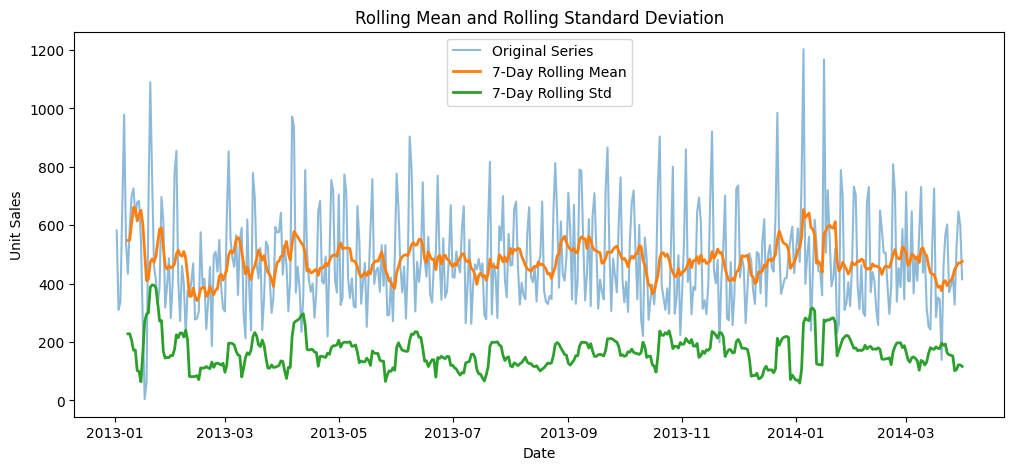

In [73]:
# Plot rolling mean and rolling standard deviation
rolling_mean = df_timeseries["unit_sales"].rolling(window=7).mean()
rolling_std = df_timeseries["unit_sales"].rolling(window=7).std()

plt.figure(figsize=(12, 5))
plt.plot(df_timeseries["date"], df_timeseries["unit_sales"], label="Original Series", alpha=0.5)
plt.plot(df_timeseries["date"], rolling_mean, label="7-Day Rolling Mean", linewidth=2)
plt.plot(df_timeseries["date"], rolling_std, label="7-Day Rolling Std", linewidth=2)
plt.title("Rolling Mean and Rolling Standard Deviation")
plt.xlabel("Date")
plt.ylabel("Unit Sales")
plt.legend()
plt.show()

In [74]:
# Perform the Augmented Dickey-Fuller test
adf_result = adfuller(df_timeseries["unit_sales"])

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"   {key}: {value}")

ADF Statistic: -5.0086145048438455
p-value: 2.133821830904239e-05
Critical Values:
   1%: -3.4454725477848998
   5%: -2.8682072297316794
   10%: -2.570321396485665


The rolling mean and rolling standard deviation show some variation over time, so the series does not appear perfectly stable from a visual perspective. However, the Augmented Dickey-Fuller test returns a very small p-value and an ADF statistic lower than all critical values, which suggests that the time series can be considered stationary in statistical terms.

# 11. Autocorrelation Analysis

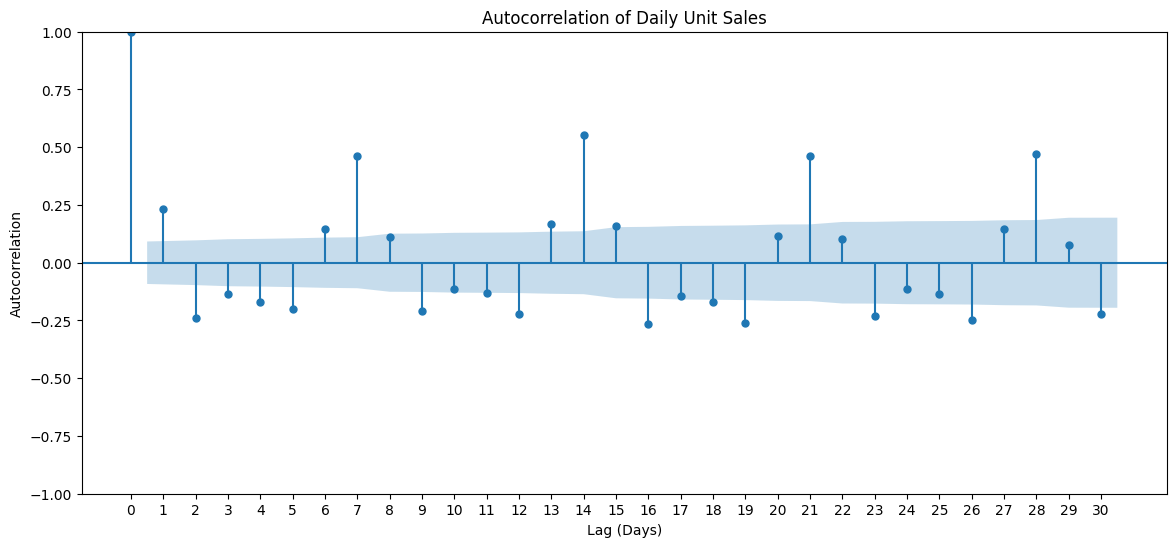

In [75]:
# Plot autocorrelation for the main time series
fig, ax = plt.subplots(figsize=(14, 6))
plot_acf(df_timeseries["unit_sales"], lags=30, ax=ax)

ax.set_title("Autocorrelation of Daily Unit Sales")
ax.set_xlabel("Lag (Days)")
ax.set_ylabel("Autocorrelation")
ax.set_xticks(range(0, 31, 1))

plt.show()

The autocorrelation plot shows statistically significant spikes at lags 7, 14, 21, and 28, which suggests a clear weekly seasonal pattern in the sales series. There is also some short-term dependence at lower lags, but the repeating 7-day structure is the most prominent feature. This result is consistent with the earlier seasonal decomposition.

# 12. Reviewing Extreme Values

In [76]:
# Review the lowest and highest sales values
display(df_timeseries[["date", "unit_sales"]].nsmallest(5, "unit_sales"))
display(df_timeseries[["date", "unit_sales"]].nlargest(5, "unit_sales"))

,date,unit_sales
15,2013-01-17,4.0
16,2013-01-18,60.0
442,2014-03-20,139.0
51,2013-02-22,186.0
323,2013-11-21,199.0


,date,unit_sales
368,2014-01-05,1203.0
379,2014-01-16,1168.0
18,2013-01-20,1090.0
354,2013-12-22,985.0
4,2013-01-06,979.0


In [77]:
# Calculate z-scores for unit sales
df_timeseries["unit_sales_zscore"] = zscore(df_timeseries["unit_sales"])

# Show observations with |z-score| > 3
display(df_timeseries.loc[df_timeseries["unit_sales_zscore"].abs() > 3, ["date", "unit_sales", "unit_sales_zscore"]])

,date,unit_sales,unit_sales_zscore
18,2013-01-20,1090.0,3.581438
368,2014-01-05,1203.0,4.244848
379,2014-01-16,1168.0,4.039367


The extreme value review suggests that the sales series contains both unusually low and unusually high observations. The lowest observed value is 4, while the z-score analysis identifies three sales values with an absolute z-score above 3, confirming that a small number of observations are statistically extreme. These findings are consistent with the histogram and boxplot, which also indicated the presence of upper outliers. However, all extreme values will be kept in the dataset, since there is not enough evidence to classify them as data errors rather than valid business events.

# 13. Cleaning Decisions

The cleaning process for the main time series focused on making the dataset suitable for time series forecasting.

The `date` column was converted to a proper datetime format, and the timeline was checked for completeness. Two missing dates were identified: 2013-12-25 and 2014-01-01. These dates were added back to create a continuous daily time series.

The missing `unit_sales` values created by this correction were filled using linear interpolation. Interpolation was selected instead of assuming zero sales because the dataset is aggregated and simplified, and there is no clear evidence that sales were actually zero on those dates.

Extreme values were reviewed but not removed, because there was not enough evidence to classify them as data errors. Temporary helper columns created during EDA were excluded from the final cleaned dataset.

# 14. Final Cleaned Dataset

In [78]:
# Create the final cleaned dataset
timeseries_cleaned = df_timeseries[["date", "unit_sales"]].copy()

# Final validation before saving
print("Final cleaned dataset validation")
print("-" * 40)

print("Date range:")
print(timeseries_cleaned["date"].min(), "to", timeseries_cleaned["date"].max())

print("\nShape:")
print(timeseries_cleaned.shape)

print("\nMissing values:")
print(timeseries_cleaned.isna().sum())

print("\nDuplicate dates:")
print(timeseries_cleaned["date"].duplicated().sum())

date_differences = timeseries_cleaned["date"].sort_values().diff().dropna()
print("\nDate frequency check:")
print(date_differences.value_counts().head())

if (date_differences == pd.Timedelta(days=1)).all():
    print("\nFinal check passed: the cleaned dataset has a continuous daily frequency.")
else:
    print("\nWarning: the cleaned dataset still contains irregular date gaps.")

display(timeseries_cleaned.head())
display(timeseries_cleaned.tail())

Final cleaned dataset validation
----------------------------------------
Date range:
2013-01-02 00:00:00 to 2014-03-31 00:00:00

Shape:
(454, 2)

Missing values:
date          0
unit_sales    0
dtype: int64

Duplicate dates:
0

Date frequency check:
date
1 days    453
Name: count, dtype: int64

Final check passed: the cleaned dataset has a continuous daily frequency.


,date,unit_sales
0,2013-01-02,582.0
1,2013-01-03,310.0
2,2013-01-04,338.0
3,2013-01-05,654.0
4,2013-01-06,979.0


,date,unit_sales
449,2014-03-27,328.0
450,2014-03-28,523.0
451,2014-03-29,647.0
452,2014-03-30,599.0
453,2014-03-31,415.0


In [79]:
# Save the cleaned time series
timeseries_cleaned.to_csv("../../data/timeseries_cleaned.csv", index=False)

print("Cleaned time series saved successfully.")
print("File path: ../../data/timeseries_cleaned.csv")

Cleaned time series saved successfully.
File path: ../../data/timeseries_cleaned.csv


In [80]:
# Reload the cleaned dataset and parse the date column
df_timeseries_cleaned = pd.read_csv(
    "../../data/timeseries_cleaned.csv",
    parse_dates=["date"]
)

display(df_timeseries_cleaned.head())
display(df_timeseries_cleaned.tail())

print("\nReloaded dataset info:")
df_timeseries_cleaned.info()

print("\nReloaded dataset validation:")
print(df_timeseries_cleaned.shape)
print(df_timeseries_cleaned.isna().sum())

,date,unit_sales
0,2013-01-02,582.0
1,2013-01-03,310.0
2,2013-01-04,338.0
3,2013-01-05,654.0
4,2013-01-06,979.0


,date,unit_sales
449,2014-03-27,328.0
450,2014-03-28,523.0
451,2014-03-29,647.0
452,2014-03-30,599.0
453,2014-03-31,415.0



Reloaded dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 454 entries, 0 to 453
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        454 non-null    datetime64[us]
 1   unit_sales  454 non-null    float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 7.2 KB

Reloaded dataset validation:
(454, 2)
date          0
unit_sales    0
dtype: int64
